# Simple refraction example

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pygimli as pg
import pygimli.meshtools as mt
import pygimli.physics.traveltime as tt

dlopen(/Users/tnm/anaconda3/envs/pg15/lib/python3.11/site-packages/pgcore/_pygimli_.so, 0x0002): Library not loaded: @rpath/libcholmod.3.dylib
  Referenced from: <D05C48BA-33ED-3C63-8331-F97D57235C73> /Users/tnm/anaconda3/envs/pg15/lib/libgimli.dylib
  Reason: tried: '/Users/tnm/anaconda3/envs/pg15/lib/libcholmod.3.dylib' (no such file), '/Users/tnm/anaconda3/envs/pg15/lib/../lib64/libcholmod.3.dylib' (no such file), '/Users/tnm/anaconda3/envs/pg15/lib/python3.11/site-packages/pgcore/../../../libcholmod.3.dylib' (no such file), '/Users/tnm/anaconda3/envs/pg15/lib/python3.11/site-packages/pgcore/../../../../lib64/libcholmod.3.dylib' (no such file), '/Users/tnm/anaconda3/envs/pg15/lib/python3.11/site-packages/pgcore/../../../libcholmod.3.dylib' (no such file), '/Users/tnm/anaconda3/envs/pg15/lib/python3.11/site-packages/pgcore/../../../../lib64/libcholmod.3.dylib' (no such file), '/Users/tnm/anaconda3/envs/pg15/bin/../lib/libcholmod.3.dylib' (no such file), '/Users/tnm/anaconda3/envs/pg1

ERROR: cannot import the library '_pygimli_'.


ImportError: cannot import name 'RVector3' from 'pygimli.core.core' (/Users/tnm/anaconda3/envs/pg15/lib/python3.11/site-packages/pygimli/core/core.py)

In [2]:
# mt.createMesh??
# mt.createPolygon??

## Create our starting model

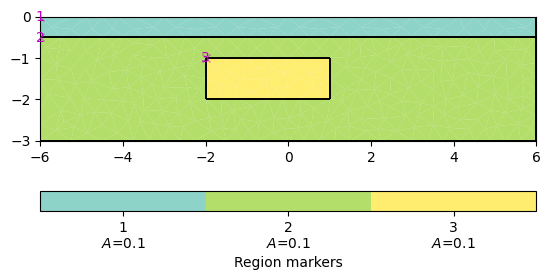

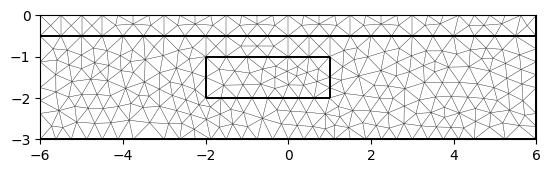

In [46]:
layer1 = mt.createPolygon([ [-6, 0], [-6, -0.5], [6,-0.5], [6, 0]], isClosed=True, marker=1, area=0.1)
layer2 = mt.createPolygon([ [-6, -0.5], [-6, -3], [6,-3], [6, -0.5]], isClosed=True, marker=2, area=0.1)
object = mt.createPolygon([ [-2, -1], [-2, -2], [1,-2], [1, -1]], isClosed=True, marker=3, area=0.1)

# geom = layer1 + layer2
geom = layer1 + layer2 + object
# geom = layer1

pg.show(geom)

mesh = mt.createMesh(geom, quality=30, area=0.1, smooth=[1, 15])
ax, _ = pg.show(mesh)


## Create the mesh with station locations on top

In [49]:
numberGeophones = 6
sensors = np.linspace(-3., 2., numberGeophones)
scheme = tt.createRAData(sensors)

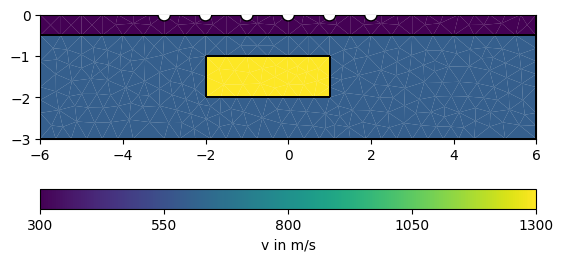

In [50]:
vp = np.array(mesh.cellMarkers())
vp[vp == 1] = 300
vp[vp == 2] = 600
vp[vp == 3] = 1300
# vp[vp == 4] = 1500

ax, _ = pg.show(mesh, vp, colorBar=True, logScale=False, label='v in m/s')
pg.viewer.mpl.drawSensors(ax, 
                          scheme.sensors(), 
                          diam=0.3,
                         facecolor='white', 
                         edgecolor='black')

## Run with real picks

Here I created a file with hammerstrikes Nr. 10 to 17. 

Data: Sensors: 6 data: 12, nonzero entries: ['err', 'g', 's', 't', 'valid']


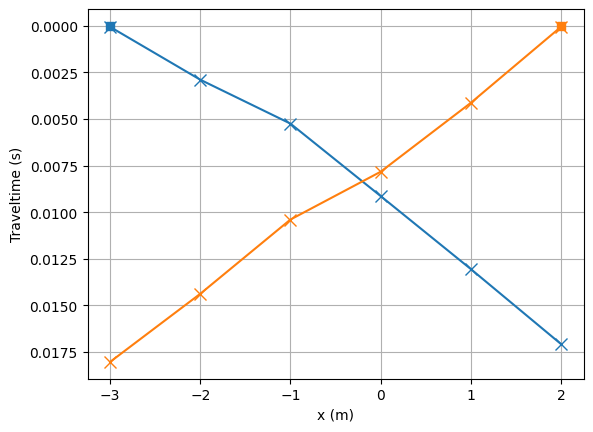

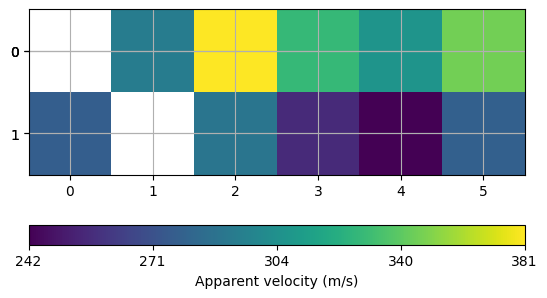

In [51]:
data = pg.load("picks_data_pg_11_18.sgt")
print(data)
tt.show(data)

mgr = tt.TravelTimeManager(data)
ax, cbar = mgr.showData()

## OR Execute with fake data to see the difference

Please only execute either the upper cell OR the one beneath. 

12/11/24 - 15:02:11 - pyGIMLi - INFO - Creating refined mesh (secnodes: 2) to solve forward task.


min/max t: 0.003333333333333333 0.009141900253852758


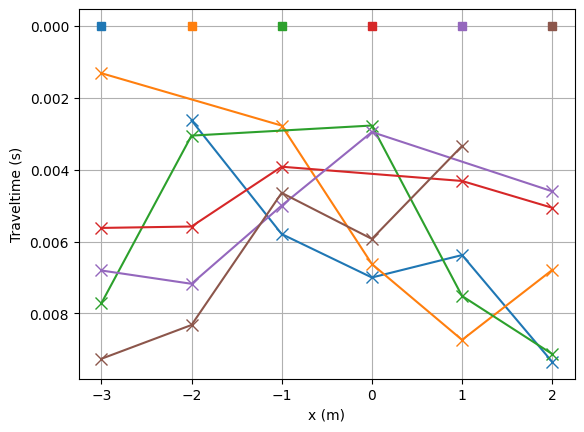

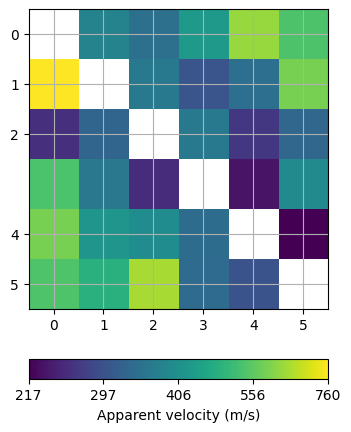

In [52]:
# generating synthetic data

data = tt.simulate(slowness=1.0 / vp, 
                   scheme=scheme, 
                   mesh=mesh,
                   noiseLevel=0.001, 
                   noiseAbs=0.001, 
                   seed=1337, 
                   verbose=True)
tt.show(data)

mgr = tt.TravelTimeManager(data)
ax, cbar = mgr.showData()

## Run the inversion

In [54]:
mgr = tt.TravelTimeManager(data)
vest = mgr.invert(secNodes=6, useGradient=True,
                  paraMaxCellSize=0.1,
                  maxIter=20, 
                  verbose=True)
try:
    np.testing.assert_array_less(mgr.inv.inv.chi2(), 1.1)
except Exception as exp:
    print(exp)

12/11/24 - 15:02:13 - pyGIMLi - INFO - Found 1 regions.
./core/src/meshentities.cpp:36		Boundary *GIMLI::findBoundary_(const std::set<Boundary *> &)  pls. check, this should not happen.  There is more than one boundary defined.2
Boundary 0x1448f9400 rtti: 22 id: 0	N: 0 1  marker: 1 
Boundary 0x14495f000 rtti: 22 id: 12	N: 4 0  marker: -1 
12/11/24 - 15:02:13 - pyGIMLi - INFO - Found 1 regions.
12/11/24 - 15:02:13 - pyGIMLi - INFO - Creating forward mesh from region infos.
12/11/24 - 15:02:13 - pyGIMLi - INFO - Creating refined mesh (secnodes: 6) to solve forward task.
12/11/24 - 15:02:13 - pyGIMLi - INFO - Create gradient starting model. 500: 5000
12/11/24 - 15:02:13 - pyGIMLi - INFO - Created startmodel from forward operator: 158, min/max=0.000200/0.002000
12/11/24 - 15:02:13 - pyGIMLi - INFO - Starting inversion.


Constructing Delaunay triangulation by divide-and-conquer method.
Delaunay milliseconds:  0
Recovering segments in Delaunay triangulation.
Segment milliseconds:  0
Removing unwanted triangles.
Spreading regional attributes and area constraints.
Hole milliseconds:  0
Adding Steiner points to enforce quality.
Quality milliseconds:  0

Writing vertices.
Writing triangles.
Writing segments.
Writing edges.

Output milliseconds:  0
Total running milliseconds:  0

Statistics:

  Input vertices: 13
  Input segments: 14
  Input holes: 0

  Mesh vertices: 96
  Mesh triangles: 158
  Mesh edges: 253
  Mesh exterior boundary edges: 32
  Mesh interior boundary edges: 0
  Mesh subsegments (constrained edges): 32

min/max(dweight) = 990.941/996.678
fop: <pygimli.physics.traveltime.modelling.TravelTimeDijkstraModelling object at 0x114420db0>
Data transformation: <pgcore._pygimli_.RTrans object at 0x137ba49a0>
Model transformation: <pgcore._pygimli_.RTransLog object at 0x137ba6980>
min/max (data): 0.001

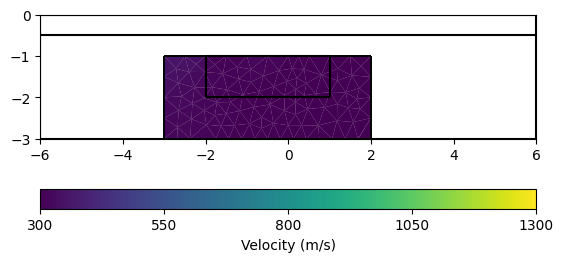

In [44]:
ax, _ = mgr.showResult(cMin=min(vp), cMax=max(vp), logScale=False)
ax, _ = pg.show(geom, ax=ax, fillRegion=False, regionMarker=True)

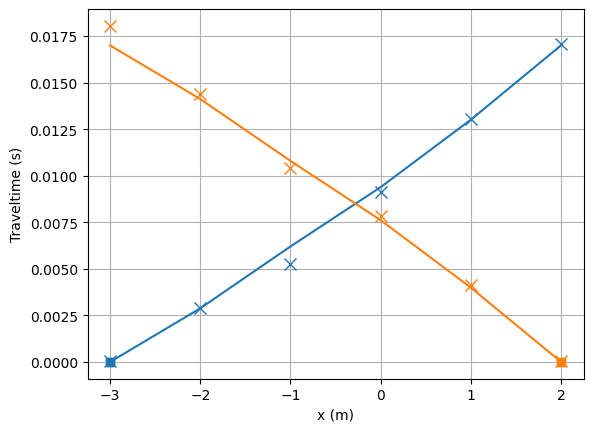

In [45]:
mgr.showFit(firstPicks=True)